In [1]:
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from collections import defaultdict
# Download latest version
path = kagglehub.dataset_download("zimbazo/backrooms-24h-survival-set")

c:\Users\david\anaconda3\envs\dm2_pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../datasets/CLF/backrooms_24h.csv")

In [3]:
print(df.shape)

(20000, 50)


In [4]:
df.head()

,character_id,age,sex,height_cm,weight_kg,strength,reaction,stamina,speed,intelligence,perception,agility,endurance,stress_resistance,luck,panic,fatigue,hunger,thirst,mental_stability,focus,confidence,pain_tolerance,has_flashlight,flashlight_battery,has_knife,has_backpack,has_first_aid_kit,medkit_count,has_water,water_amount,has_food,food_amount,has_radio,level_id,level_difficulty,visibility,entity_density,entity_aggression,resource_density,maze_complexity,geometry_stability,spawn_area_danger,distance_to_nearest_entity,noise_generated,time_since_last_encounter,special_rule,survived_24h,survival_time_hours,escape_probability
0,1,34,M,195.0,101.5,87.06,22.97,89.96,83.26,57.57,43.09,27.56,64.99,80.99,24.68,2.38,14.04,21.95,30.60,39.94,58.19,43.14,63.83,1,42.57,0,0,1,3,0,0.00,1,6.80,1,2,3.07,31.44,31.42,11.75,66.34,8.57,52.40,11.75,86.86,0.43,72.11,none,0,200.25,86.88
1,2,26,M,176.4,81.3,50.75,7.71,42.38,61.29,15.08,39.68,20.07,24.37,40.86,38.76,40.10,44.67,49.84,52.83,25.35,4.74,2.09,20.94,0,0.00,0,1,0,0,1,1.54,0,0.00,1,end,5.50,66.73,49.88,36.85,23.07,65.36,66.73,36.85,56.62,12.22,62.29,trap_exit,0,50.34,22.27
2,3,42,F,174.2,89.3,43.02,17.08,43.14,46.84,48.64,32.80,16.14,15.88,40.80,62.40,10.67,25.48,23.00,30.42,26.82,44.15,8.09,18.01,1,33.98,1,0,1,3,1,3.28,1,6.36,1,6,4.16,18.22,86.71,26.72,61.72,39.52,72.89,26.72,19.79,3.26,67.30,darkness,1,203.04,75.99
3,4,28,F,171.4,81.9,37.73,11.21,36.29,38.45,13.40,50.18,17.25,32.66,94.56,93.05,0.90,13.54,10.10,15.89,79.83,14.71,23.45,37.49,1,15.46,1,1,0,0,1,3.84,1,7.54,1,5,5.50,85.47,28.10,20.37,74.15,30.12,85.47,20.37,88.42,0.84,70.11,none,1,183.76,81.38
4,5,39,F,164.2,83.6,35.77,23.50,30.38,31.13,53.34,29.20,16.91,31.79,78.71,11.77,1.95,20.17,12.10,17.28,32.53,52.75,9.86,27.06,1,39.84,0,1,0,0,1,3.57,1,6.98,1,0,4.17,41.03,27.25,5.25,68.17,51.22,41.03,5.25,90.79,0.36,71.25,none,1,179.34,67.58


In [5]:
colonne_binarie = [col for col in df.columns if df[col].nunique() == 2]
print("Colonne binarie:", colonne_binarie)

Colonne binarie: ['sex', 'has_flashlight', 'has_knife', 'has_backpack', 'has_first_aid_kit', 'has_water', 'has_food', 'has_radio', 'survived_24h']


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
le = LabelEncoder()
for a in colonne_binarie:
    df[a] = le.fit_transform(df[a])

df = pd.get_dummies(df, drop_first=True, dtype=int)
escluse = ['character_id', 'survival_time_hours', 'escape_probability']
df.drop(escluse, axis=1, inplace=True)
df.head()

,age,sex,height_cm,weight_kg,strength,reaction,stamina,speed,intelligence,perception,agility,endurance,stress_resistance,luck,panic,fatigue,hunger,thirst,mental_stability,focus,confidence,pain_tolerance,has_flashlight,flashlight_battery,has_knife,has_backpack,has_first_aid_kit,medkit_count,has_water,water_amount,has_food,food_amount,has_radio,level_difficulty,visibility,entity_density,entity_aggression,resource_density,maze_complexity,geometry_stability,spawn_area_danger,distance_to_nearest_entity,noise_generated,time_since_last_encounter,survived_24h,level_id_1,level_id_2,level_id_3,level_id_4,level_id_5,level_id_6,level_id_7,level_id_8,level_id_end,special_rule_flooding,special_rule_none,special_rule_trap_exit
0,34,1,195.0,101.5,87.06,22.97,89.96,83.26,57.57,43.09,27.56,64.99,80.99,24.68,2.38,14.04,21.95,30.60,39.94,58.19,43.14,63.83,1,42.57,0,0,1,3,0,0.00,1,6.80,1,3.07,31.44,31.42,11.75,66.34,8.57,52.40,11.75,86.86,0.43,72.11,0,0,1,0,0,0,0,0,0,0,0,1,0
1,26,1,176.4,81.3,50.75,7.71,42.38,61.29,15.08,39.68,20.07,24.37,40.86,38.76,40.10,44.67,49.84,52.83,25.35,4.74,2.09,20.94,0,0.00,0,1,0,0,1,1.54,0,0.00,1,5.50,66.73,49.88,36.85,23.07,65.36,66.73,36.85,56.62,12.22,62.29,0,0,0,0,0,0,0,0,0,1,0,0,1
2,42,0,174.2,89.3,43.02,17.08,43.14,46.84,48.64,32.80,16.14,15.88,40.80,62.40,10.67,25.48,23.00,30.42,26.82,44.15,8.09,18.01,1,33.98,1,0,1,3,1,3.28,1,6.36,1,4.16,18.22,86.71,26.72,61.72,39.52,72.89,26.72,19.79,3.26,67.30,1,0,0,0,0,0,1,0,0,0,0,0,0
3,28,0,171.4,81.9,37.73,11.21,36.29,38.45,13.40,50.18,17.25,32.66,94.56,93.05,0.90,13.54,10.10,15.89,79.83,14.71,23.45,37.49,1,15.46,1,1,0,0,1,3.84,1,7.54,1,5.50,85.47,28.10,20.37,74.15,30.12,85.47,20.37,88.42,0.84,70.11,1,0,0,0,0,1,0,0,0,0,0,1,0
4,39,0,164.2,83.6,35.77,23.50,30.38,31.13,53.34,29.20,16.91,31.79,78.71,11.77,1.95,20.17,12.10,17.28,32.53,52.75,9.86,27.06,1,39.84,0,1,0,0,1,3.57,1,6.98,1,4.17,41.03,27.25,5.25,68.17,51.22,41.03,5.25,90.79,0.36,71.25,1,0,0,0,0,0,0,0,0,0,0,1,0


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
attributes = [col for col in df.columns if col != 'survived_24h']
X = df[attributes].values
y = df['survived_24h']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [11]:
print(pd.Series(y_train).value_counts())

survived_24h
1    8864
0    5136
Name: count, dtype: int64


# PCA

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [13]:
def plot_pca(X_pca, y_train):
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
    plt.show()

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
pca = PCA(n_components=2)
pca.fit(X_train_scaled)
X_pca = pca.transform(X_train_scaled)
print(X_train_scaled.shape, X_pca.shape)

(14000, 56) (14000, 2)


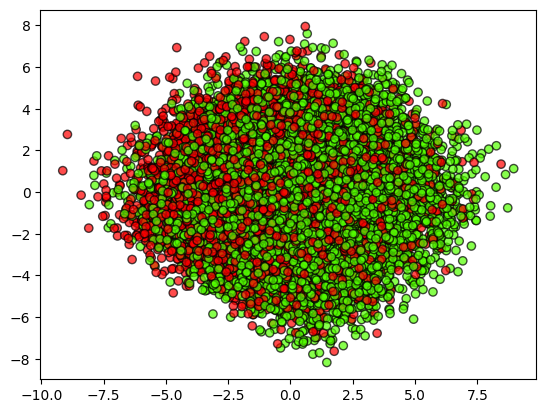

In [15]:
plot_pca(X_pca,y_train)

In [16]:
np.histogram(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])

(array([27,  4,  0,  5,  5,  0,  9,  2,  3,  1]),
 array([5.72162806e-02, 7.00871402e+01, 1.40117064e+02, 2.10146988e+02,
        2.80176912e+02, 3.50206836e+02, 4.20236760e+02, 4.90266684e+02,
        5.60296608e+02, 6.30326531e+02, 7.00356455e+02]))

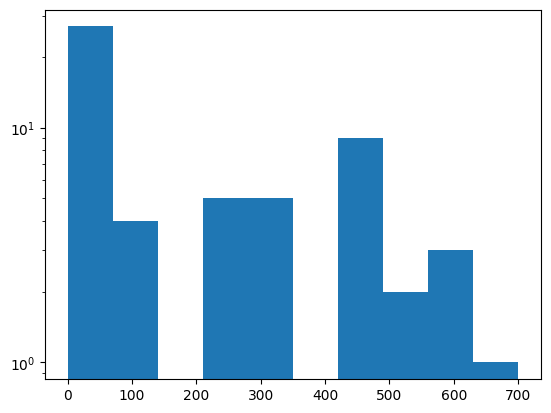

In [17]:
plt.hist(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])
plt.yscale('log')
plt.show()

# Decision Tree

In [18]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [19]:
dt = DecisionTreeClassifier()

In [20]:
%%time
dt.fit(X_train, y_train)

CPU times: total: 703 ms
Wall time: 698 ms


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


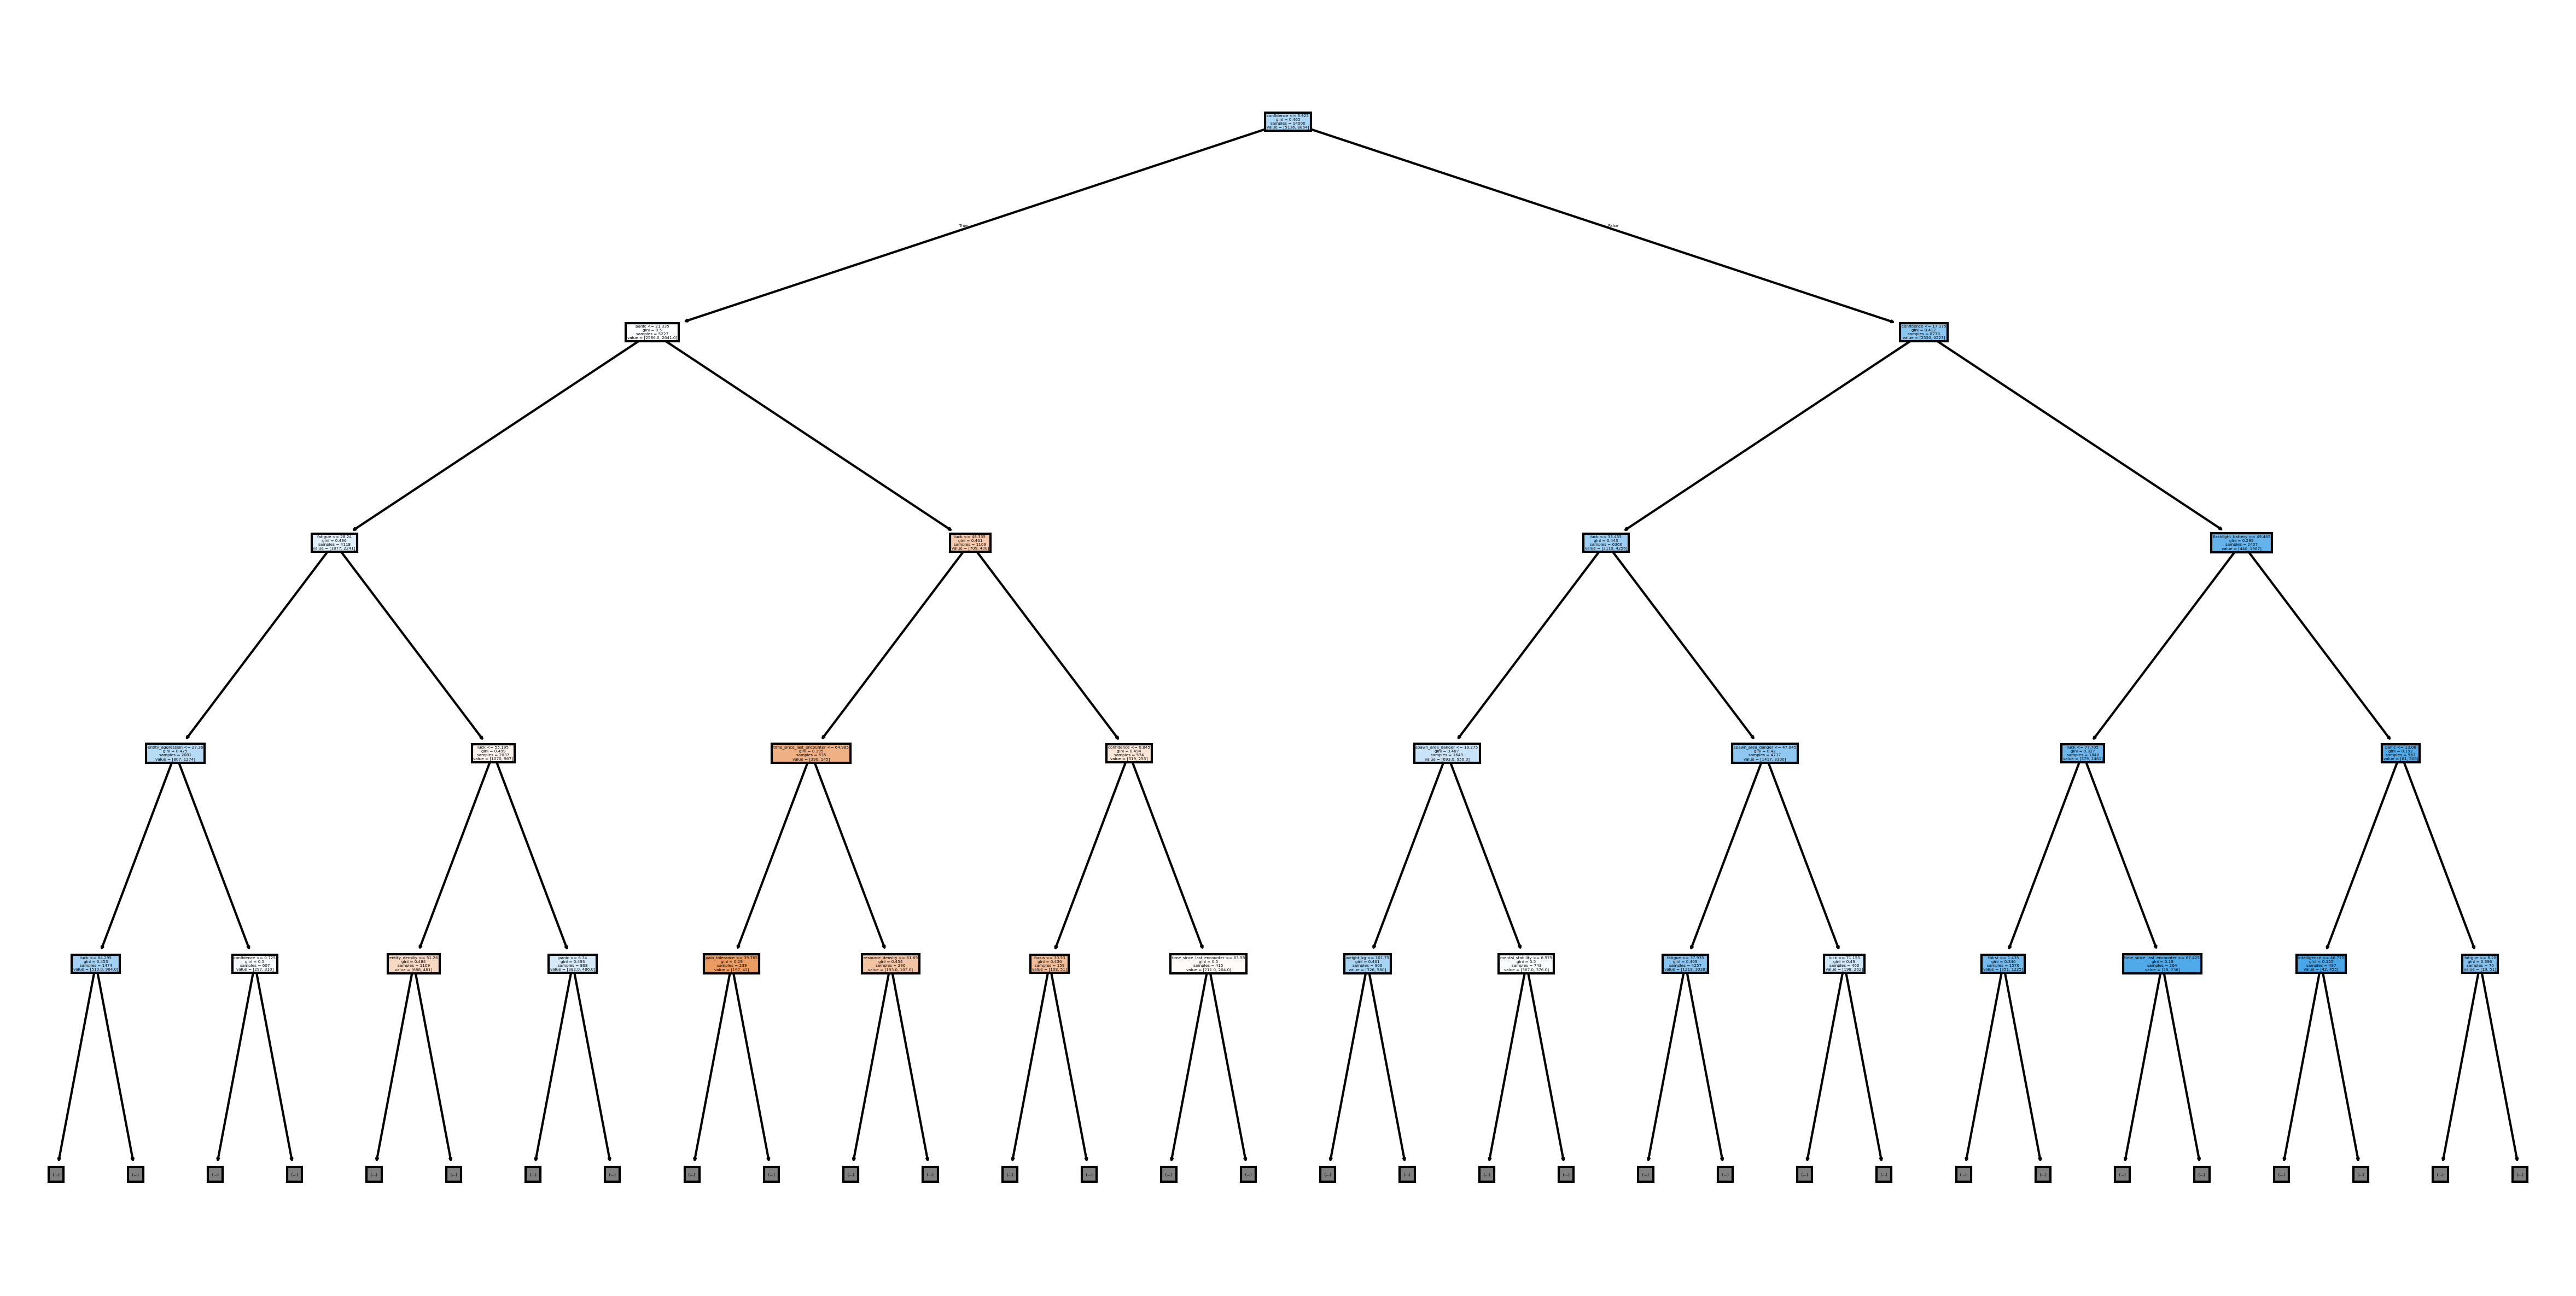

In [21]:
plt.figure(figsize=(20, 10), dpi=300)
plot_tree(dt, feature_names=attributes, filled=True, max_depth = 4)
plt.show()

In [22]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [23]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

In [24]:
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print()

print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))

Train Accuracy 1.0
Train F1-score [1. 1.]

Test Accuracy 0.5905
Test F1-score [0.44699527 0.67487098]


In [25]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.44      0.45      0.45      2201
           1       0.68      0.67      0.67      3799

    accuracy                           0.59      6000
   macro avg       0.56      0.56      0.56      6000
weighted avg       0.59      0.59      0.59      6000



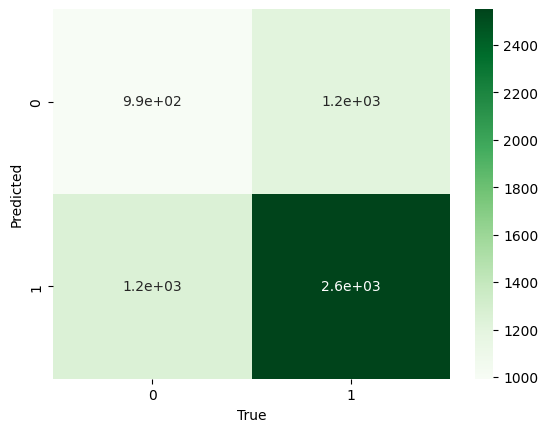

In [26]:
cf = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cf, annot=True, cmap="Greens")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

# Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
clf = RandomForestClassifier()

In [29]:
%%time
clf.fit(X_train, y_train)

CPU times: total: 6.19 s
Wall time: 6.37 s


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

In [31]:
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print()

print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))

Train Accuracy 1.0
Train F1-score [1. 1.]

Test Accuracy 0.6618333333333334
Test F1-score [0.41307492 0.76249561]


In [32]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.57      0.32      0.41      2201
           1       0.69      0.86      0.76      3799

    accuracy                           0.66      6000
   macro avg       0.63      0.59      0.59      6000
weighted avg       0.64      0.66      0.63      6000



In [33]:
# assicurati di avere il repo in sys.path e di rimuovere i moduli caricati
import sys, os
repo_path = r'C:\Users\david\RuleTree'
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)
for _m in list(sys.modules):
    if _m == 'RuleTree' or _m.startswith('RuleTree.'):
        del sys.modules[_m]

In [34]:
!pip install category_encoders


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\david\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [35]:
!pip install tempfile312


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\david\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [36]:
!pip install numba


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\david\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [37]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=1100, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_test_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Accuracy 0.6531666666666667
F1-score [0.42017275 0.7525859 ]
              precision    recall  f1-score   support

           0       0.54      0.34      0.42      2201
           1       0.69      0.83      0.75      3799

    accuracy                           0.65      6000
   macro avg       0.61      0.59      0.59      6000
weighted avg       0.63      0.65      0.63      6000

Fidelity of Trepan to the original model: 0.8203333333333334


In [38]:
from sklearn.model_selection import cross_val_score

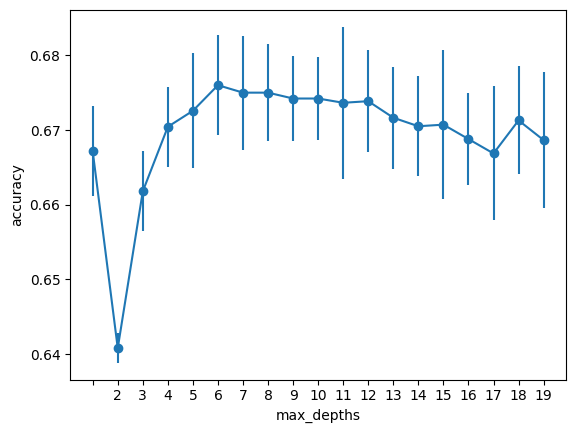

In [39]:
max_depths = [None] + list(np.arange(2, 20))
avg_scores = list()
std_scores = list()

for max_depth in max_depths:
    dt = RandomForestClassifier(max_depth=max_depth)
    scores = cross_val_score(dt, X_train, y_train, cv=5)
    avg_scores.append(np.mean(scores))
    std_scores.append(np.std(scores))

plt.errorbar(range(len(max_depths)), y=avg_scores, yerr=std_scores, marker='o')
plt.xticks(range(len(max_depths)), max_depths)
plt.xlabel("max_depths")
plt.ylabel("accuracy")
plt.show()

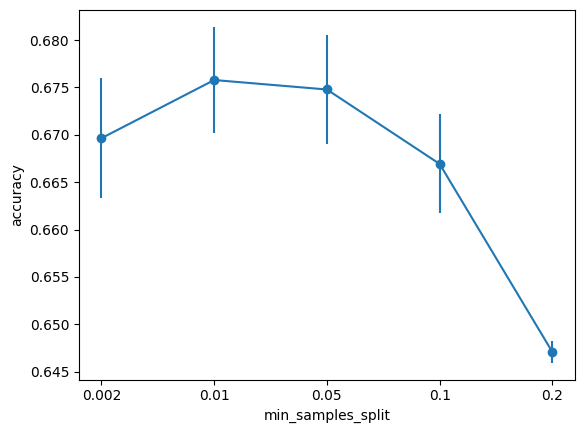

In [40]:
min_samples_splits = [0.002, 0.01, 0.05, 0.1, 0.2]
avg_scores = list()
std_scores = list()

for min_samples_split in min_samples_splits:
    dt = RandomForestClassifier(min_samples_split=min_samples_split)
    scores = cross_val_score(dt, X_train, y_train, cv=5)
    avg_scores.append(np.mean(scores))
    std_scores.append(np.std(scores))

plt.errorbar(range(len(min_samples_splits)), y=avg_scores, yerr=std_scores, marker='o')
plt.xticks(range(len(min_samples_splits)), min_samples_splits)
plt.xlabel("min_samples_split")
plt.ylabel("accuracy")
plt.show()

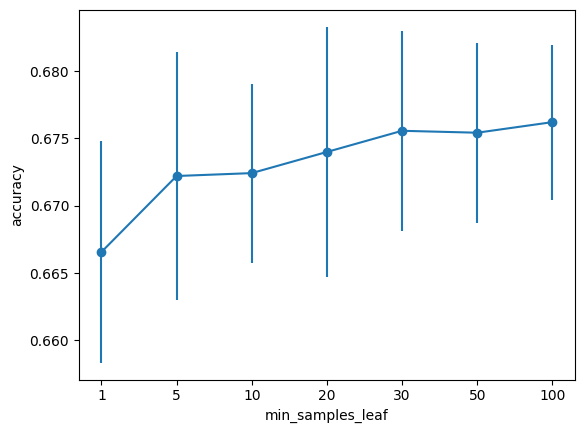

In [41]:
min_samples_leafs = [1, 5, 10, 20, 30, 50, 100]
avg_scores = list()
std_scores = list()

for min_samples_leaf in min_samples_leafs:
    dt = RandomForestClassifier(min_samples_leaf=min_samples_leaf)
    scores = cross_val_score(dt, X_train, y_train, cv=5)
    avg_scores.append(np.mean(scores))
    std_scores.append(np.std(scores))

plt.errorbar(range(len(min_samples_leafs)), y=avg_scores, yerr=std_scores, marker='o')
plt.xticks(range(len(min_samples_leafs)), min_samples_leafs)
plt.xlabel("min_samples_leaf")
plt.ylabel("accuracy")
plt.show()

In [42]:
from sklearn.model_selection import RandomizedSearchCV

In [44]:
%%time
param_list = {
    'max_depth': list(np.arange(5, 8)),
    'n_estimators' : [200,500],
    'min_samples_split': [2, 5, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10, 20, 30],
    'criterion': ['gini', 'entropy'],
    'bootstrap': [True, False],
    'max_features': ['log2', 'sqrt'],
    'class_weight' : ['balanced']
    
}

clf = RandomForestClassifier(criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    RandomForestClassifier(),
    param_distributions=param_list,
    cv=3,
    n_jobs=-1,
    refit=True,
    n_iter=50,
    #verbose=2
)

random_search.fit(X_train, y_train)
clf = random_search.best_estimator_

CPU times: total: 8.34 s
Wall time: 7min 10s


In [45]:
print(random_search.best_params_, random_search.best_score_)

{'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': np.int64(7), 'criterion': 'gini', 'class_weight': 'balanced', 'bootstrap': True} 0.642857379025618


In [46]:
y_test_pred = clf.predict(X_test)
y_train_pred = clf.predict(X_train)
print("Accuracy:", accuracy_score(y_test, y_test_pred))

Accuracy: 0.6478333333333334


In [47]:
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print()

print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))

Train Accuracy 0.6990714285714286
Train F1-score [0.62137144 0.75031115]

Test Accuracy 0.6478333333333334
Test F1-score [0.55933264 0.70673144]


In [48]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.52      0.61      0.56      2201
           1       0.75      0.67      0.71      3799

    accuracy                           0.65      6000
   macro avg       0.63      0.64      0.63      6000
weighted avg       0.66      0.65      0.65      6000



In [49]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, max_leaf_nodes=25,  prune_useless_leaves=True, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_test_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Accuracy 0.6508333333333334
F1-score [0.47716496 0.73789566]
              precision    recall  f1-score   support

           0       0.53      0.43      0.48      2201
           1       0.70      0.78      0.74      3799

    accuracy                           0.65      6000
   macro avg       0.62      0.61      0.61      6000
weighted avg       0.64      0.65      0.64      6000

Fidelity of Trepan to the original model: 0.8236666666666667


# Bagging 

In [50]:
from sklearn.ensemble import BaggingClassifier

In [51]:
albero_base = DecisionTreeClassifier(class_weight='balanced')
clf = BaggingClassifier(estimator=albero_base, n_estimators=100, 
                        random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6648333333333334
F1-score [0.41928963 0.76443716]
              precision    recall  f1-score   support

           0       0.58      0.33      0.42      2201
           1       0.69      0.86      0.76      3799

    accuracy                           0.66      6000
   macro avg       0.63      0.59      0.59      6000
weighted avg       0.65      0.66      0.64      6000



In [ ]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, max_leaf_nodes=25,  prune_useless_leaves=True, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Accuracy 0.6573333333333333
F1-score [0.36109385 0.76588476]
              precision    recall  f1-score   support

           0       0.57      0.26      0.36      2201
           1       0.67      0.89      0.77      3799

    accuracy                           0.66      6000
   macro avg       0.62      0.57      0.56      6000
weighted avg       0.64      0.66      0.62      6000

Fidelity of Trepan to the original model: 0.8488333333333333


In [ ]:
clf = BaggingClassifier(estimator=RandomForestClassifier(n_estimators=100, class_weight='balanced'), n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6708333333333333
F1-score [0.37834435 0.77615324]
              precision    recall  f1-score   support

           0       0.62      0.27      0.38      2201
           1       0.68      0.90      0.78      3799

    accuracy                           0.67      6000
   macro avg       0.65      0.59      0.58      6000
weighted avg       0.66      0.67      0.63      6000



In [ ]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, max_leaf_nodes=25,  prune_useless_leaves=True, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Accuracy 0.6638333333333334
F1-score [0.40272431 0.76609069]
              precision    recall  f1-score   support

           0       0.58      0.31      0.40      2201
           1       0.68      0.87      0.77      3799

    accuracy                           0.66      6000
   macro avg       0.63      0.59      0.58      6000
weighted avg       0.65      0.66      0.63      6000

Fidelity of Trepan to the original model: 0.8726666666666667


# Boosting

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
albero_base = DecisionTreeClassifier(class_weight='balanced')
clf = AdaBoostClassifier(estimator=albero_base, n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5853333333333334
F1-score [0.43633892 0.67202742]
              precision    recall  f1-score   support

           0       0.44      0.44      0.44      2201
           1       0.67      0.67      0.67      3799

    accuracy                           0.59      6000
   macro avg       0.55      0.55      0.55      6000
weighted avg       0.59      0.59      0.59      6000



In [ ]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=100, max_leaf_nodes=20, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Accuracy 0.636
F1-score [0.4734812 0.7218543]
              precision    recall  f1-score   support

           0       0.50      0.45      0.47      2201
           1       0.70      0.75      0.72      3799

    accuracy                           0.64      6000
   macro avg       0.60      0.60      0.60      6000
weighted avg       0.63      0.64      0.63      6000

Fidelity of Trepan to the original model: 0.6266666666666667


In [ ]:
clf = AdaBoostClassifier(estimator=RandomForestClassifier(n_estimators=100,class_weight='balanced' ), n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6696666666666666
F1-score [0.41011905 0.77060185]
              precision    recall  f1-score   support

           0       0.59      0.31      0.41      2201
           1       0.69      0.88      0.77      3799

    accuracy                           0.67      6000
   macro avg       0.64      0.59      0.59      6000
weighted avg       0.65      0.67      0.64      6000



In [ ]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=2000, max_leaf_nodes=25,  prune_useless_leaves=True, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Accuracy 0.6573333333333333
F1-score [0.36109385 0.76588476]
              precision    recall  f1-score   support

           0       0.57      0.26      0.36      2201
           1       0.67      0.89      0.77      3799

    accuracy                           0.66      6000
   macro avg       0.62      0.57      0.56      6000
weighted avg       0.64      0.66      0.62      6000

Fidelity of Trepan to the original model: 0.857


# Gradient Boosting

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

In [ ]:
pesi = compute_sample_weight(class_weight='balanced', y=y_train)
clf = GradientBoostingClassifier(n_estimators=100, 
                                 learning_rate=1.0, max_depth=3, random_state=0)
clf.fit(X_train, y_train, sample_weight=pesi)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.604
F1-score [0.50664452 0.66926503]
              precision    recall  f1-score   support

           0       0.47      0.55      0.51      2201
           1       0.71      0.63      0.67      3799

    accuracy                           0.60      6000
   macro avg       0.59      0.59      0.59      6000
weighted avg       0.62      0.60      0.61      6000



In [ ]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=500, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Accuracy 0.6521666666666667
F1-score [0.46936181 0.74129168]
              precision    recall  f1-score   support

           0       0.53      0.42      0.47      2201
           1       0.70      0.79      0.74      3799

    accuracy                           0.65      6000
   macro avg       0.62      0.60      0.61      6000
weighted avg       0.64      0.65      0.64      6000

Fidelity of Trepan to the original model: 0.7048333333333333


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [ ]:
clf = HistGradientBoostingClassifier(learning_rate=1.0, max_depth=3, random_state=0, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6263333333333333
F1-score [0.5497992  0.68062678]
              precision    recall  f1-score   support

           0       0.49      0.62      0.55      2201
           1       0.74      0.63      0.68      3799

    accuracy                           0.63      6000
   macro avg       0.62      0.63      0.62      6000
weighted avg       0.65      0.63      0.63      6000



In [ ]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, max_depth = 6 , max_leaf_nodes = 20,  random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Accuracy 0.6553333333333333
F1-score [0.49927361 0.73722999]
              precision    recall  f1-score   support

           0       0.53      0.47      0.50      2201
           1       0.71      0.76      0.74      3799

    accuracy                           0.66      6000
   macro avg       0.62      0.62      0.62      6000
weighted avg       0.65      0.66      0.65      6000

Fidelity of Trepan to the original model: 0.7933333333333333


# XGBOOST

In [ ]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import xgboost as xgb

In [ ]:
clf = xgb.XGBClassifier(objective='binary:logistic', 
                    max_depth = 13,
                    learning_rate = 0.1,
                    gamma = 0.5,
                    reg_lambda = 1,
                    tree_method='exact', # 'approx'
                    random_state=42,
                    scale_pos_weight = 0.45
                    
                   )
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6335
F1-score [0.49897471 0.71107607]
              precision    recall  f1-score   support

           0       0.50      0.50      0.50      2201
           1       0.71      0.71      0.71      3799

    accuracy                           0.63      6000
   macro avg       0.61      0.60      0.61      6000
weighted avg       0.63      0.63      0.63      6000



In [ ]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=1350, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Accuracy 0.6603333333333333
F1-score [0.41234141 0.76113455]
              precision    recall  f1-score   support

           0       0.56      0.32      0.41      2201
           1       0.69      0.85      0.76      3799

    accuracy                           0.66      6000
   macro avg       0.63      0.59      0.59      6000
weighted avg       0.64      0.66      0.63      6000

Fidelity of Trepan to the original model: 0.7668333333333334


# Optuna

In [ ]:
pip install optuna

In [ ]:
import optuna

In [ ]:

def objective(trial):
    param = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "scale_pos_weight" : 0.45
    }

    model = xgb.XGBClassifier(
        **param,
    )

    score = cross_val_score(model, X_train, y_train, cv=3, scoring="roc_auc").mean()
    return score

In [ ]:

study = optuna.create_study(study_name="xgboost_study_cpu", direction="maximize")
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=-1)


best_params = study.best_params
print(f"\nBest parameters: {best_params}")

[I 2026-07-01 00:51:11,337] A new study created in memory with name: xgboost_study_cpu


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-01 00:51:16,125] Trial 2 finished with value: 0.6815068941414316 and parameters: {'max_depth': 5, 'learning_rate': 0.08111703465724089, 'n_estimators': 274, 'subsample': 0.9519661389741916, 'colsample_bytree': 0.5765119538290701, 'min_child_weight': 4, 'gamma': 3.4681642063054463}. Best is trial 2 with value: 0.6815068941414316.
[I 2026-07-01 00:51:18,487] Trial 1 finished with value: 0.6750703025205494 and parameters: {'max_depth': 3, 'learning_rate': 0.09713962292355999, 'n_estimators': 291, 'subsample': 0.86124550840651, 'colsample_bytree': 0.8193953164406214, 'min_child_weight': 4, 'gamma': 1.5839025427033522}. Best is trial 2 with value: 0.6815068941414316.
[I 2026-07-01 00:51:18,579] Trial 0 finished with value: 0.6872424430024336 and parameters: {'max_depth': 3, 'learning_rate': 0.0572331528561363, 'n_estimators': 479, 'subsample': 0.8534812906503741, 'colsample_bytree': 0.5201251859074597, 'min_child_weight': 8, 'gamma': 3.8851677437145944}. Best is trial 0 with valu

In [ ]:
best = study.best_params
print(best)

{'max_depth': 3, 'learning_rate': 0.023657704882956397, 'n_estimators': 188, 'subsample': 0.6307123047317301, 'colsample_bytree': 0.5543624596798846, 'min_child_weight': 8, 'gamma': 2.694310711522577}


In [ ]:
clf = xgb.XGBClassifier(**best)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_train_pred = clf.predict(X_train)
print('Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6899285714285714
F1-score [0.44195912 0.78532219]
Accuracy 0.6743333333333333
F1-score [0.40823743 0.77535066]
              precision    recall  f1-score   support

           0       0.61      0.31      0.41      2201
           1       0.69      0.89      0.78      3799

    accuracy                           0.67      6000
   macro avg       0.65      0.60      0.59      6000
weighted avg       0.66      0.67      0.64      6000



In [ ]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, max_leaf_nodes=25,  prune_useless_leaves=True, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

# LightGBM

In [ ]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
clf = LGBMClassifier(boosting_type='gbdt',  #'goss', #'dart'
                     max_depth=-1, # no limit
                     num_leaves=31,
                     n_estimators=100,
                     subsample_for_bin=200000,
                     objective='binary',
                     reg_alpha=0.0, #L1 regularization term on weights
                     reg_lambda=0.0, #L2 regularization term on weights
                     random_state=42,
                     class_weight='balanced'
                   )
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 8864, number of negative: 5136
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8682
[LightGBM] [Info] Number of data points in the train set: 14000, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Accuracy 0.6401666666666667
F1-score [0.54364828 0.70298528]
              precision    recall  f1-score   support

           0       0.51      0.58      0.54      2201
           1       0.74      0.67      0.70      3799

    accuracy                           0.64      6000
   macro avg       0.62      0.63      0.62      6000
weighted avg       0.65      0.64      0.64      6000



In [ ]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, max_leaf_nodes=25,  prune_useless_leaves=True, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Accuracy 0.6585
F1-score [0.47609307 0.74669304]
              precision    recall  f1-score   support

           0       0.54      0.42      0.48      2201
           1       0.70      0.79      0.75      3799

    accuracy                           0.66      6000
   macro avg       0.62      0.61      0.61      6000
weighted avg       0.65      0.66      0.65      6000

Fidelity of Trepan to the original model: 0.7886666666666666


# CatBOOST

In [ ]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from catboost import CatBoostClassifier

In [ ]:
clf = CatBoostClassifier(auto_class_weights='Balanced')
clf.fit(X_train, y_train)

Learning rate set to 0.031793
0:	learn: 0.6905163	total: 144ms	remaining: 2m 23s
1:	learn: 0.6881008	total: 156ms	remaining: 1m 17s
2:	learn: 0.6854687	total: 165ms	remaining: 54.7s
3:	learn: 0.6832645	total: 176ms	remaining: 43.9s
4:	learn: 0.6809393	total: 187ms	remaining: 37.2s
5:	learn: 0.6788780	total: 196ms	remaining: 32.5s
6:	learn: 0.6765869	total: 209ms	remaining: 29.7s
7:	learn: 0.6743569	total: 222ms	remaining: 27.5s
8:	learn: 0.6722479	total: 234ms	remaining: 25.7s
9:	learn: 0.6703991	total: 243ms	remaining: 24s
10:	learn: 0.6686375	total: 255ms	remaining: 22.9s
11:	learn: 0.6669948	total: 266ms	remaining: 21.9s
12:	learn: 0.6651229	total: 274ms	remaining: 20.8s
13:	learn: 0.6638054	total: 284ms	remaining: 20s
14:	learn: 0.6623874	total: 293ms	remaining: 19.2s
15:	learn: 0.6610136	total: 302ms	remaining: 18.6s
16:	learn: 0.6598281	total: 313ms	remaining: 18.1s
17:	learn: 0.6586850	total: 323ms	remaining: 17.6s
18:	learn: 0.6575299	total: 333ms	remaining: 17.2s
19:	learn: 0.

CatBoostClassifier(auto_class_weights='Balanced')

In [ ]:
y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6483333333333333
F1-score [0.55010661 0.71135431]
              precision    recall  f1-score   support

           0       0.52      0.59      0.55      2201
           1       0.74      0.68      0.71      3799

    accuracy                           0.65      6000
   macro avg       0.63      0.64      0.63      6000
weighted avg       0.66      0.65      0.65      6000



In [ ]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=1000, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Accuracy 0.6531666666666667
F1-score [0.46185674 0.74412886]
              precision    recall  f1-score   support

           0       0.54      0.41      0.46      2201
           1       0.70      0.80      0.74      3799

    accuracy                           0.65      6000
   macro avg       0.62      0.60      0.60      6000
weighted avg       0.64      0.65      0.64      6000

Fidelity of Trepan to the original model: 0.7865
